In [63]:
import pandas as pd
import sklearn as skl
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import recall_score, precision_score, plot_confusion_matrix, f1_score, ConfusionMatrixDisplay
import seaborn as sns
import numpy as np
from imblearn.over_sampling import RandomOverSampler

In [64]:
main_df = pd.read_csv('energy-train.csv')
holdout = pd.read_csv('energy-holdout.csv')

In [65]:
main_df.Appliances.unique()
# holdout.describe()

array([ 60, 140,  50, 120,  90, 240, 130, 100,  30,  70,  40, 390, 200,
        80, 150, 260, 160, 190, 210, 280, 250, 310, 470, 110,  20, 270,
       340, 750, 230, 580, 570, 220, 400, 410, 660, 610, 600, 490, 380,
       350, 180, 330, 290, 770, 670, 440, 630, 430, 710, 170, 520, 510,
       650, 500, 360, 320, 370, 560, 480, 300, 460, 450, 640, 540, 420,
       740, 550, 530, 760, 850, 690, 680, 590, 900, 700, 620,  10, 780,
       890, 720, 790, 800, 860, 730])

In [66]:
main_dummy_df = pd.get_dummies(main_df, drop_first=True)
main_dummy_df

,Year,Month,Day,Hours,Minutes,Time-since-start,Appliances,lights,T1,RH_1,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016,5,10,14,50,17267,60,0,25.200000,47.126667,...,24.100000,47.525714,18.800,750.150000,78.000000,4.500000,40.000000,14.800,41.358725,41.358725
1,2016,5,4,21,50,16445,60,0,23.390000,33.790000,...,20.390000,34.463333,10.900,764.283333,57.333333,3.000000,40.000000,2.770,9.024852,9.024852
2,2016,3,16,20,20,9380,140,20,22.600000,37.360000,...,19.600000,36.200000,5.270,765.200000,62.000000,5.666667,23.333333,-1.500,49.291757,49.291757
3,2016,3,19,2,30,9705,50,0,21.790000,36.760000,...,19.700000,39.560000,4.700,762.300000,92.000000,3.500000,62.500000,3.500,0.102888,0.102888
4,2016,3,11,5,40,8572,50,0,20.500000,36.200000,...,18.166667,41.090000,-0.767,763.600000,93.666667,1.333333,33.000000,-1.700,8.882974,8.882974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13895,2016,3,30,8,10,11323,110,0,21.500000,40.500000,...,20.356667,41.200000,7.550,751.683333,82.333333,4.000000,40.000000,4.650,37.772855,37.772855
13896,2016,4,15,16,30,13677,80,0,22.700000,39.290000,...,20.890000,42.730000,15.500,746.850000,51.833333,8.833333,30.000000,5.580,27.577899,27.577899
13897,2016,3,10,15,40,8488,60,0,21.066667,36.290000,...,18.100000,40.663333,9.830,759.333333,54.333333,1.666667,22.000000,0.967,20.786560,20.786560
13898,2016,5,20,20,0,18738,70,0,23.500000,44.326667,...,22.600000,43.790000,17.300,758.100000,56.000000,4.000000,40.000000,8.500,6.127469,6.127469


In [67]:

dtc = RandomForestClassifier(max_samples=2, class_weight='balanced_subsample', \
    max_features=None, random_state=2)
# dtc = RandomForestClassifier(class_weight='balanced_', random_state=11)

X = main_dummy_df.drop(['Appliances'],axis = 1)
y = main_dummy_df['Appliances']

ros = RandomOverSampler(random_state=11)
xee, yee = ros.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(xee, yee, test_size = 0.5, random_state = 42)
X_val, _, y_val, _ = train_test_split(X_test, y_test, test_size = 0.5, random_state = 42)

dtc.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced_subsample', max_features=None,
                       max_samples=2, random_state=2)

/home/mathidiot/miniconda3/envs/tf/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.
  warnings.warn(msg, category=FutureWarning)


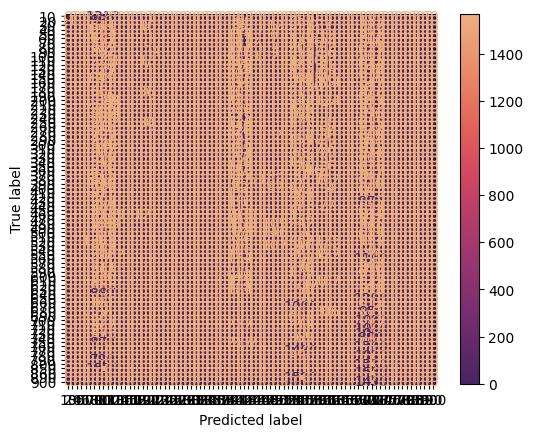

In [68]:
y_pred = dtc.predict(X_val)
pred_df = pd.DataFrame()
pred_df['prediction'] = y_pred
pred_df.to_csv('main_holdout_predictions.csv', index=False)
con_mat = plot_confusion_matrix(dtc, X_test, y_test, cmap='flare_r')

In [69]:
score = dtc.score(X_val, y_val)
# recall = recall_score(list(y_val), y_pred)
# precision = precision_score(y_val, y_pred)
# score, recall, precision, len(y_pred)
score

0.01545461677257394

In [70]:
holdout_predictions = dtc.predict(holdout)
holdout_predictions = pd.DataFrame(holdout_predictions)
holdout_predictions = holdout_predictions.rename(columns={0: 'Appliances'})
holdout_predictions.to_csv('tree-holdout-predicstions.csv', index=None)